# Neural Network creation for Pump-valves block data

***

**Author:** Juan M. Montes-Sánchez

**GitHub:** https://github.com/juamonsan

***

In this notebook you will find a step by step guide where you will:
- Load data taken with FP-SNS-DATALOG1 on a STEVAL-MKSBOX1V1FP-SNS-DATALOG and pre-processed as .csv files with "Dataset preparation" notebook from this same project
- Split the data into train, evaluation and test
- Generate and train a Neural Network capable of classifing lectures from the sensors
- Generating plots and metrics related to the data or the Neural Network

## Requirements

You **MUST** have:
- Data in .csv and with a proper folder structure created with "Dataset preparation" notebook from this same project

Optional requirements include:
- CUDA compatible Nvidia GPU

## Previous steps

### Neural Network environment: Importing Keras/Tensorflow

Import tensorflow and check if we have GPUs availables. If so, it means a GPU is ready to be used for tensorflow training.

In [1]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.layers import LSTM, GRU, Dropout
from tensorflow.keras.optimizers import Adam, SGD

from tensorflow.keras.utils import to_categorical

import sys

print("Python version {}.{}".format(sys.version_info.major, sys.version_info.minor))

print("Tensorflow version " + tf.__version__)

Python version 3.7
Tensorflow version 2.1.0


In [2]:
from tensorflow.python.client import device_lib

num_GPUs=len(tf.config.experimental.list_physical_devices('GPU'))

tf.config.list_physical_devices('GPU')

device_lib.list_local_devices()

tf.test.is_built_with_cuda()

tf.debugging.set_log_device_placement(True)


if(num_GPUs>0):
    print("Your system has {} GPUs availables".format(num_GPUs))
else:
    print("No GPUs available")    


Your system has 1 GPUs availables


---
If we have a Nvidia GPU with drivers and CUDA properly installed we can also get some extra information: GPU model, driver and CUDA versions, activity...

In [3]:
# GPU count and name
!nvidia-smi -L
# GPU activity
!nvidia-smi

GPU 0: NVIDIA GeForce GTX 1650 (UUID: GPU-235cadad-b6ee-9e16-4bcd-63bcc7b79e19)
Tue Jun 27 14:58:05 2023       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.98                 Driver Version: 535.98       CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  | 00000000:01:00.0 Off |                  N/A |
| N/A   51C    P0              14W /  50W |    158MiB /  4096MiB |      0%      Default |
|                                         |                      |            

---
### Other imports

In [4]:
# More imports
import matplotlib.pyplot as plt #for plotting raw data
import os #for system folders and files management
import pathlib #for system folders and files management
import pandas as pd #for Dataframe handling

import numpy as np
import math
import csv

from IPython.display import Audio #for WAV generation

# End

In [5]:
# Make numpy values easier to read.
np.set_printoptions(precision=3, suppress=True)

### Definitions

In [6]:
# Dando la ruta del fichero CSV, muestra una grafica de los datos
def plot_record(file_path, xName, yName):
    data = pd.read_csv(file_path, sep=',')
    data = data.to_numpy()
    print("Shape of the data is: {}".format(np.shape(data)))
    #plt.plot(data[:,0], data[:,1], #if we have a timestamp at column 0
    #         data[:,0], data[:,2],
    #         data[:,0], data[:,3])
    plt.plot(range(np.shape(data)[0]), data[:,0],
             range(np.shape(data)[0]), data[:,1],
             range(np.shape(data)[0]), data[:,2])
    plt.xlabel(xName)
    plt.ylabel(yName)
    #plt.xlim((0, 200))
    #plt.ylim((-1500, 1500))

## Loading data

### Loading from CSV



Select data folder and extract data size from the content of the files. We are going to consider the data is already in the desired format.

Number of samples: 996
Sample size: 550
Number of features: 3
-----------------------
Plot example for first file:
-----------------------
The class for this file is 3
Shape of the data is: (549, 3)


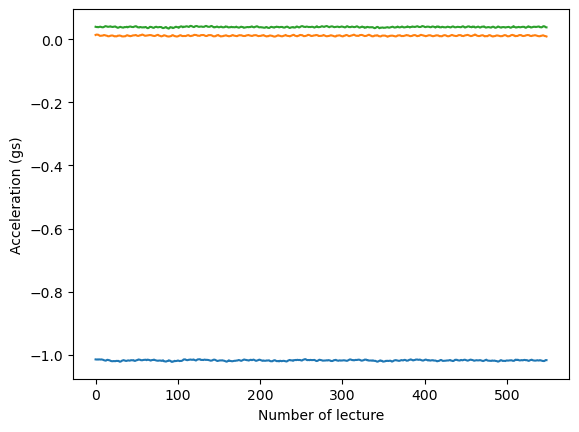

In [7]:
csv_folder_path="DATA\\expData\\STBOX_00002_Windows" #Select desired path
sensor_folder="ACC_LIS3DHH_1100Hz" #Select desired sensor folder

full_path=os.path.join(csv_folder_path,sensor_folder)

Current_file_path = os.path.join(full_path,os.listdir(full_path)[0])

Current_file = open(Current_file_path) # Open first file for counting rows

num_samples= len(os.listdir(full_path)) #number of .csv files in total
tam_samples= len(Current_file.readlines())#number of lectures in a window sample (rows in each .csv)
num_features = 3 #axis number (3 for accel) TODO: read column number from the file

print("Number of samples: {}\nSample size: {}\nNumber of features: {}".format(num_samples,tam_samples,num_features))
print("-----------------------\nPlot example for first file:\n-----------------------")

file_class=int(Current_file_path[-6:-4]) # Class is in the filename, at the end, just before file extension
print("The class for this file is {}".format(file_class))

plot_record(Current_file_path, 'Number of lecture', 'Acceleration (gs)')

Current_file.close() # Close file

Using the variables from above cell, we create two training numpy arrays for feeding the NN: one contains the data (trainX) and the other the desired outputs in one hot format (trainY)

In [8]:
DataX=np.empty([num_samples, tam_samples, num_features]) # Empty numpy array we will fill with data from .csv files
DataY=np.empty([num_samples])

for i in range (num_samples):
    Current_file_path = os.path.join(full_path,os.listdir(full_path)[i])
    Current_CSV=np.genfromtxt (Current_file_path, delimiter=",")
    DataX[i]=Current_CSV
    
    file_class=int(Current_file_path[-6:-4])
    DataY[i]=file_class-1
    #print("{} (Class {})".format(Current_file_path,file_class))
#    if file_class == 1:
#        DataY[i]='001'
#    elif file_class == 2:
#        DataY[i]='010'
#    elif file_class == 3:
#        DataY[i]='100'
#    else:
#        print("ERROR")
#        DataY[i]='000'

DataY = to_categorical(DataY)        
print("The shape of DataX array is: {}".format(np.shape(DataX))) # We check if the shape is correct
print("The shape of DataY array is: {}".format(np.shape(DataY)))    
    

The shape of DataX array is: (996, 550, 3)
The shape of DataY array is: (996, 3)


#### Split the data

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(DataX, DataY, test_size=0.3, random_state=100, stratify=DataY)
print("X_train shape: {} || X_test shape: {}".format(np.shape(X_train), np.shape(X_test))) # We check if the shape is correct
print("y_train shape: {} || y_test shape: {}".format(np.shape(y_train), np.shape(y_test)))

X_train shape: (697, 550, 3) || X_test shape: (299, 550, 3)
y_train shape: (697, 3) || y_test shape: (299, 3)


### Network definition

In [10]:
#Copiado de notebook de Curro (definiciones de distintas RNN):

def create_1layer_lstm_model(nodes,drp):
    
    input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(LSTM((nodes)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_1layer_gru_model(nodes,drp):
    
    input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(GRU((nodes)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_2layer_lstm_model(nodes_1stl,nodes_2ndl,drp):
    
    input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(LSTM((nodes_1stl), return_sequences=True))
    rnn_model.add(Dropout(drp))
    rnn_model.add(LSTM((nodes_2ndl)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_2layer_gru_model(nodes_1stl,nodes_2ndl,drp):
    
    input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(GRU((nodes_1stl), return_sequences=True))
    rnn_model.add(Dropout(drp))
    rnn_model.add(GRU((nodes_2ndl)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model

#### NN training


In [11]:
#Create

nodes_1 = 32
nodes_2 = 16
drp = 0.3

model_lstm_2l = create_2layer_lstm_model(nodes_1,nodes_2,drp)
model_lstm_2l.summary()

Executing op Fill in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarIsInitializedOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op LogicalNot in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Assert in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op RandomUniform in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Sub in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Mul in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Add in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op RandomStandardNormal in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Qr in device /job:localhost/replica:0/tas

In [12]:
#Compile

opt = tf.keras.optimizers.Adam(learning_rate=0.002)

model_lstm_2l.compile(loss='categorical_crossentropy',
        optimizer=opt,
        metrics=["accuracy"])

Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0


In [32]:
#Train

epochs = 500
batch_size = 32

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.h5", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.0001
    ),
    #keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, verbose=1),
]


#model_lstm_2l.fit(X_train, y_train, batch_size = batch_size,epochs = epochs, validation_data = (X_test, y_test))
with tf.device('/gpu:0'):
    history = model_lstm_2l.fit(
        X_train,
        y_train,
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks,
        validation_data = (X_test, y_test),
        verbose=1,
    )

Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op Prefet

697/697 [==============================] - 1s 1ms/sample - loss: 0.0858 - accuracy: 0.9756 - val_loss: 0.0978 - val_accuracy: 0.9699
Epoch 49/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0975 - accuracy: 0.9727 - val_loss: 0.0974 - val_accuracy: 0.9732
Epoch 50/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0901 - accuracy: 0.9770 - val_loss: 0.0856 - val_accuracy: 0.9766
Epoch 51/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0877 - accuracy: 0.9756 - val_loss: 0.0786 - val_accuracy: 0.9799
Epoch 52/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0683 - accuracy: 0.9785 - val_loss: 0.0770 - val_accuracy: 0.9799
Epoch 53/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0727 - accuracy: 0.9799 - val_loss: 0.0767 - val_accuracy: 0.9766
Epoch 54/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0681 - accuracy: 0.9813 - val_loss: 0.0740 - val_accuracy

Epoch 75/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0387 - accuracy: 0.9914 - val_loss: 0.0815 - val_accuracy: 0.9833
Epoch 76/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0436 - accuracy: 0.9900 - val_loss: 0.0836 - val_accuracy: 0.9833
Epoch 77/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0537 - accuracy: 0.9871 - val_loss: 0.0833 - val_accuracy: 0.9833
Epoch 78/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0470 - accuracy: 0.9900 - val_loss: 0.0831 - val_accuracy: 0.9833
Epoch 79/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0408 - accuracy: 0.9914 - val_loss: 0.0723 - val_accuracy: 0.9866
Epoch 80/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0382 - accuracy: 0.9914 - val_loss: 0.0721 - val_accuracy: 0.9866
Epoch 81/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0417 - accuracy: 0.9900 - val_loss: 0.0717 -

697/697 [==============================] - 1s 1ms/sample - loss: 0.0307 - accuracy: 0.9914 - val_loss: 0.0677 - val_accuracy: 0.9866
Epoch 102/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0421 - accuracy: 0.9900 - val_loss: 0.0677 - val_accuracy: 0.9866
Epoch 103/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0240 - accuracy: 0.9957 - val_loss: 0.0678 - val_accuracy: 0.9866
Epoch 104/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0236 - accuracy: 0.9957 - val_loss: 0.0677 - val_accuracy: 0.9866
Epoch 105/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0355 - accuracy: 0.9900 - val_loss: 0.0676 - val_accuracy: 0.9866
Epoch 106/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0318 - accuracy: 0.9928 - val_loss: 0.0674 - val_accuracy: 0.9866
Epoch 107/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0445 - accuracy: 0.9885 - val_loss: 0.0672 - val_ac

Epoch 128/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0140 - accuracy: 0.9986 - val_loss: 0.0607 - val_accuracy: 0.9900
Epoch 129/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0182 - accuracy: 0.9986 - val_loss: 0.0606 - val_accuracy: 0.9900
Epoch 130/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0265 - accuracy: 0.9943 - val_loss: 0.0597 - val_accuracy: 0.9900
Epoch 131/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0273 - accuracy: 0.9943 - val_loss: 0.0579 - val_accuracy: 0.9900
Epoch 132/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0152 - accuracy: 0.9971 - val_loss: 0.0574 - val_accuracy: 0.9900
Epoch 133/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0171 - accuracy: 0.9986 - val_loss: 0.0573 - val_accuracy: 0.9900
Epoch 134/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0222 - accuracy: 0.9971 - val_loss: 0

...

697/697 [==============================] - 1s 1ms/sample - loss: 0.0325 - accuracy: 0.9943 - val_loss: 0.0746 - val_accuracy: 0.9866
Epoch 285/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0085 - accuracy: 0.9971 - val_loss: 0.0480 - val_accuracy: 0.9933
Epoch 286/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0108 - accuracy: 0.9986 - val_loss: 0.0483 - val_accuracy: 0.9933
Epoch 287/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0165 - accuracy: 0.9986 - val_loss: 0.0484 - val_accuracy: 0.9933
Epoch 288/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0048 - accuracy: 1.0000 - val_loss: 0.0485 - val_accuracy: 0.9933
Epoch 289/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0058 - accuracy: 1.0000 - val_loss: 0.0486 - val_accuracy: 0.9933
Epoch 290/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0113 - accuracy: 0.9986 - val_loss: 0.0487 - val_ac

697/697 [==============================] - 1s 1ms/sample - loss: 0.0200 - accuracy: 0.9957 - val_loss: 0.0570 - val_accuracy: 0.9900
Epoch 337/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0103 - accuracy: 0.9971 - val_loss: 0.0583 - val_accuracy: 0.9900
Epoch 338/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0117 - accuracy: 0.9986 - val_loss: 0.0581 - val_accuracy: 0.9900
Epoch 339/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0243 - accuracy: 0.9943 - val_loss: 0.1721 - val_accuracy: 0.9565
Epoch 340/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.2378 - accuracy: 0.9498 - val_loss: 0.1525 - val_accuracy: 0.9599
Epoch 341/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0779 - accuracy: 0.9799 - val_loss: 0.0329 - val_accuracy: 0.9900
Epoch 342/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0220 - accuracy: 0.9971 - val_loss: 0.0405 - val_ac

697/697 [==============================] - 1s 1ms/sample - loss: 0.0069 - accuracy: 0.9986 - val_loss: 0.0401 - val_accuracy: 0.9933
Epoch 389/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0072 - accuracy: 0.9986 - val_loss: 0.0398 - val_accuracy: 0.9933
Epoch 390/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0056 - accuracy: 1.0000 - val_loss: 0.0398 - val_accuracy: 0.9933
Epoch 391/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0067 - accuracy: 0.9986 - val_loss: 0.0395 - val_accuracy: 0.9933
Epoch 392/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0048 - accuracy: 1.0000 - val_loss: 0.0395 - val_accuracy: 0.9933
Epoch 393/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0048 - accuracy: 1.0000 - val_loss: 0.0395 - val_accuracy: 0.9933
Epoch 394/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0041 - accuracy: 1.0000 - val_loss: 0.0395 - val_ac

697/697 [==============================] - 1s 1ms/sample - loss: 0.0035 - accuracy: 1.0000 - val_loss: 0.0408 - val_accuracy: 0.9933
Epoch 441/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0044 - accuracy: 1.0000 - val_loss: 0.0406 - val_accuracy: 0.9933
Epoch 442/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0028 - accuracy: 1.0000 - val_loss: 0.0407 - val_accuracy: 0.9933
Epoch 443/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0032 - accuracy: 1.0000 - val_loss: 0.0408 - val_accuracy: 0.9933
Epoch 444/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0049 - accuracy: 0.9986 - val_loss: 0.0409 - val_accuracy: 0.9933
Epoch 445/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0039 - accuracy: 1.0000 - val_loss: 0.0410 - val_accuracy: 0.9933
Epoch 446/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0049 - accuracy: 0.9986 - val_loss: 0.0410 - val_ac

697/697 [==============================] - 1s 1ms/sample - loss: 0.0122 - accuracy: 0.9971 - val_loss: 0.0538 - val_accuracy: 0.9900
Epoch 493/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0043 - accuracy: 0.9986 - val_loss: 0.0552 - val_accuracy: 0.9900
Epoch 494/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0030 - accuracy: 1.0000 - val_loss: 0.0513 - val_accuracy: 0.9933
Epoch 495/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0027 - accuracy: 1.0000 - val_loss: 0.0516 - val_accuracy: 0.9933
Epoch 496/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0024 - accuracy: 1.0000 - val_loss: 0.0517 - val_accuracy: 0.9933
Epoch 497/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0028 - accuracy: 1.0000 - val_loss: 0.0517 - val_accuracy: 0.9933
Epoch 498/500
697/697 [==============================] - 1s 1ms/sample - loss: 0.0026 - accuracy: 1.0000 - val_loss: 0.0518 - val_ac

In [33]:
#Model save
best_model_lstm_name = 'best_model_lstm.h5'
models_folder = "DATA\\models"
sensor_model_folder=os.path.join(models_folder,sensor_folder) 

if not os.path.exists(sensor_model_folder): 
                os.makedirs(sensor_model_folder)


model_lstm_2l.save(os.path.join(sensor_model_folder, best_model_lstm_name))

## Evaluation

In [34]:
model = tf.keras.models.load_model(os.path.join(sensor_model_folder, best_model_lstm_name))
pred = model.predict(X_test)
pred

Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op DestroyResourceOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ParallelMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ModelDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op __inference_distributed_function_115317 in device /job:localhost/replica:0/task:0

array([[0.   , 1.   , 0.   ],
       [0.999, 0.001, 0.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 0.   , 1.   ],
       [0.999, 0.001, 0.   ],
       [0.   , 0.   , 1.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 0.   , 1.   ],
       [0.999, 0.001, 0.   ],
       [0.999, 0.001, 0.   ],
       [0.   , 1.   , 0.   ],
       [0.999, 0.001, 0.   ],
       [0.991, 0.009, 0.   ],
       [0.   , 0.   , 1.   ],
       [0.   , 0.   , 1.   ],
       [0.   , 0.   , 1.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 0.   , 1.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ],
       [0.999, 0.001, 0.   ],
       [0.   , 0.   , 1.   ],
       [0.001, 0.999, 0.   ],
       [0.   , 1.   , 0.   ],
       [0.003, 0.997, 0.   ],
       [0.   , 0.   , 1.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 0.   , 1.   ],
       [0.   , 0.   , 1.   ],
       [0.

In [26]:
y_pred = np.argmax(pred, axis = 1)
#y_pred = to_categorical(y_pred) 
y_pred

array([1, 0, 1, 2, 0, 2, 1, 2, 0, 0, 1, 0, 0, 2, 2, 2, 1, 1, 0, 2, 1, 1,
       0, 2, 0, 1, 0, 2, 1, 1, 1, 2, 2, 2, 0, 0, 0, 0, 2, 2, 2, 0, 2, 0,
       0, 1, 0, 1, 0, 2, 2, 0, 0, 1, 2, 0, 0, 1, 0, 1, 0, 0, 2, 1, 1, 2,
       2, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 2, 1, 0, 2, 0, 1, 0, 0, 2, 1,
       2, 1, 1, 2, 2, 1, 2, 0, 2, 0, 0, 2, 0, 0, 0, 1, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 0, 0, 2, 0, 1, 0, 2, 1, 2, 0, 0, 0, 1, 2, 1, 0, 2, 0, 1,
       0, 0, 0, 1, 2, 1, 1, 2, 0, 2, 0, 0, 0, 2, 1, 2, 1, 2, 0, 0, 0, 0,
       0, 1, 2, 0, 1, 0, 2, 0, 0, 2, 0, 1, 1, 2, 2, 0, 1, 0, 1, 2, 1, 1,
       0, 2, 2, 2, 0, 2, 2, 0, 2, 2, 1, 0, 1, 1, 0, 2, 1, 1, 0, 2, 1, 1,
       0, 2, 0, 1, 0, 2, 1, 2, 1, 0, 1, 1, 0, 2, 2, 0, 0, 1, 2, 1, 2, 0,
       2, 1, 1, 0, 2, 0, 0, 1, 1, 2, 0, 1, 1, 2, 2, 0, 2, 1, 0, 2, 0, 1,
       1, 1, 1, 1, 2, 2, 1, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 1, 1, 2,
       2, 2, 1, 0, 1, 0, 1, 0, 1, 2, 0, 0, 2, 2, 1, 2, 0, 0, 2, 1, 1, 1,
       2, 2, 1, 2, 2, 0, 2, 1, 0, 2, 1, 1, 2], dtyp

In [35]:
import sklearn.model_selection
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [36]:
p = sklearn.metrics.confusion_matrix(y_test.argmax(axis=1), y_pred, labels=[0,1,2])
p

array([[91,  0,  0],
       [20, 94,  0],
       [ 0,  0, 94]], dtype=int64)

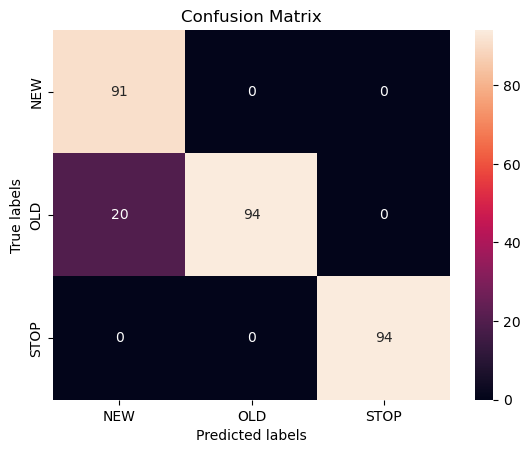

In [39]:
import seaborn as sns

T_lables = ['STOP','NEW','OLD']    

ax= plt.subplot()

#cm = confusion_matrix(np.asarray(y_test).argmax(axis=1), np.asarray(y_pred))
sns.heatmap(p, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(T_lables); ax.yaxis.set_ticklabels(T_lables);

---
## Data plot

### Metrics for raw data

This section contains code for getting metrics from raw data and generating plot images

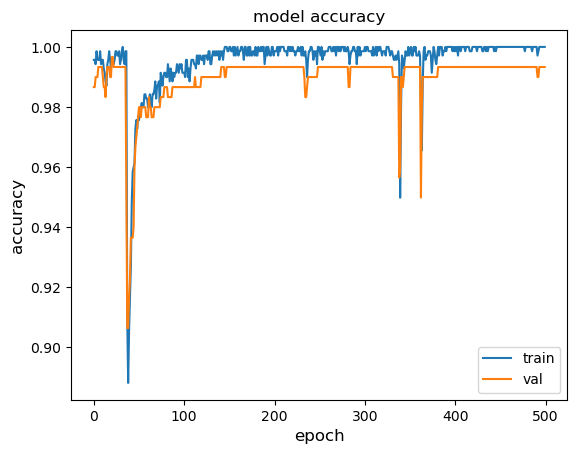

In [38]:
metric = "accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()


In [ ]:
# TO DO: METRICS AND PLOT CODE

---
### Metrics for data converted to CSV
This section contains code for getting metrics from raw data and generating plot images

In [ ]:
# TO DO: METRICS AND PLOT CODE

In [ ]:
#fft = tf.signal.rfft(df['T (degC)'])

from scipy.fft import fftfreq 
#plt.style.use("seaborn")

t = df["Time"].loc[df["Time"] > 5].loc[df["Time"] < 10]
s = df["A_z [g]"].loc[df["Time"] > 5].loc[df["Time"] < 10]

fft = np.fft.fft(s)
fft[0] = 0
fftfreq = np.fft.fftfreq(len(s))*len(s)/(t.max()-t.min())

plt.subplot(1, 2, 1)
plt.xlabel("Frequency Domain")
plt.ylabel("Amplitude")
plt.plot(fftfreq, fft)
plt.subplot(1, 2, 2)
plt.plot(t, s)
plt.show()



#### Normalization - mean window

In [ ]:
#estoy hay que mirárselo...

class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])


#### Downsample

Only in case we want to decrease the amount of data (simulating a lower frequency) we can run the next code:

In [ ]:
# para reducir la frecuencia se puede usar! TODO ajustar al ODR
# Slice [start:stop:step], starting from index 5 take every 110th record.-> 1100
df_sliced = df[5::110]
df_sliced.head()